# Standard Random Forest Classifier - Lung Cancer Dataset

This notebook trains a standard (non-private) Random Forest classifier on the Lung Cancer dataset (50,000 samples, 23 features, 3-class target) to establish baseline performance.

## 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)
import pickle
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


## 2. Load Preprocessed Data

In [2]:
with open('../data/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"\nFeatures: {feature_names}")

Training data shape: (40000, 23)
Test data shape: (10000, 23)
Number of features: 23

Features: ['Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain', 'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough', 'Snoring']


## 3. Train Standard Random Forest Model

In [3]:
rf_model = RandomForestClassifier(
    n_estimators=20,
    max_depth=4,
    random_state=42,
    n_jobs=-1
)

print("Training Standard Random Forest...")
_t0 = time.perf_counter()
rf_model.fit(X_train, y_train)
train_time = time.perf_counter() - _t0
# Score the non-private fit on the training partition too, so the
# generalisation gap can be read next to the held-out metrics.
y_train_pred = rf_model.predict(X_train)
print("Training complete!")

Training Standard Random Forest...
Training complete!


## 4. Make Predictions

In [4]:
y_pred = rf_model.predict(X_test)

print(f"Predictions shape: {y_pred.shape}")

Predictions shape: (10000,)


## 5. Model Evaluation

In [5]:
extra = ExtraMetrics()
accuracy = accuracy_score(y_test, y_pred)
extra.add(y_test, y_pred, model=rf_model, X=X_test, train_true=y_train, train_pred=y_train_pred, train_time=train_time)
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("=" * 60)
print("STANDARD RANDOM FOREST - PERFORMANCE METRICS")
print("=" * 60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-Score:  {f1:.4f} (weighted)")
print(f"Precision: {precision:.4f} (weighted)")
print(f"Recall:    {recall:.4f} (weighted)")
print("=" * 60)

STANDARD RANDOM FOREST - PERFORMANCE METRICS
Accuracy:  1.0000
F1-Score:  1.0000 (weighted)
Precision: 1.0000 (weighted)
Recall:    1.0000 (weighted)


## 6. Confusion Matrix

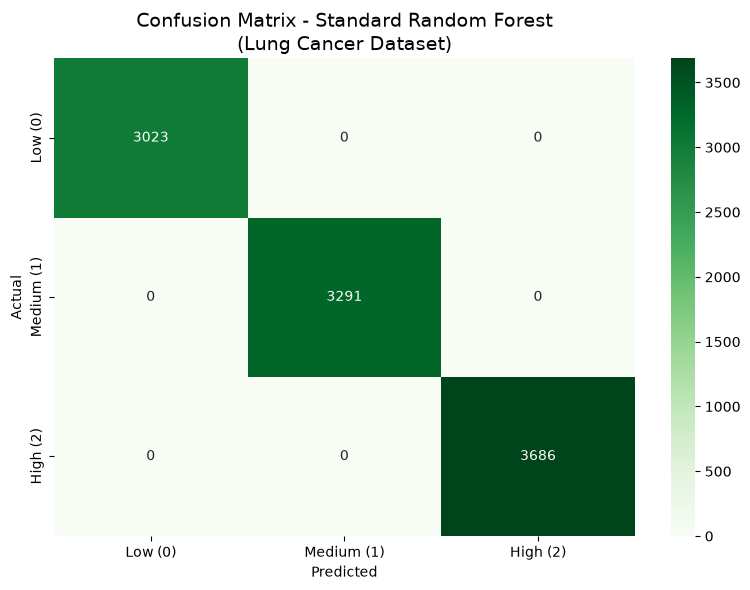

In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low (0)', 'Medium (1)', 'High (2)'],
            yticklabels=['Low (0)', 'Medium (1)', 'High (2)'])
plt.title('Confusion Matrix - Standard Random Forest\n(Lung Cancer Dataset)', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 7. Feature Importance

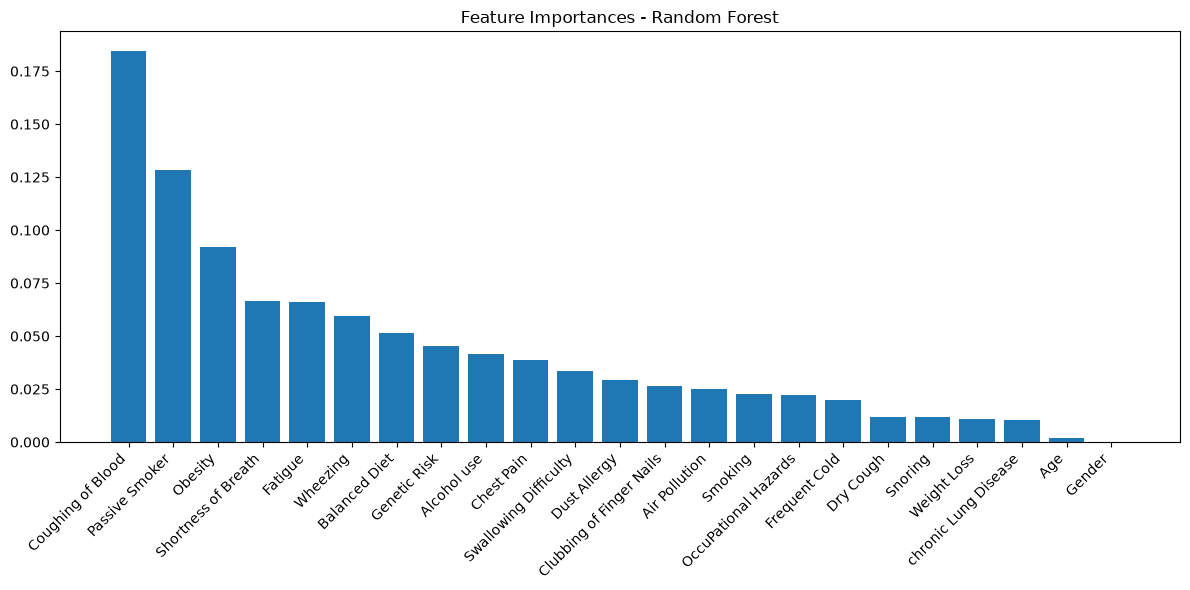

Top 10 features:
            feature  importance
  Coughing of Blood    0.184564
     Passive Smoker    0.128431
            Obesity    0.091866
Shortness of Breath    0.066692
            Fatigue    0.066139
           Wheezing    0.059268
      Balanced Diet    0.051619
       Genetic Risk    0.045392
        Alcohol use    0.041362
         Chest Pain    0.038539


In [7]:
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(range(len(feat_df)), feat_df['importance'])
plt.xticks(range(len(feat_df)), feat_df['feature'], rotation=45, ha='right')
plt.title('Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(feat_df.head(10).to_string(index=False))

## 8. Classification Report

In [8]:
print("Classification Report:")
print(classification_report(y_test, y_pred,
                          target_names=['Low (0)', 'Medium (1)', 'High (2)']))

Classification Report:
              precision    recall  f1-score   support

     Low (0)       1.00      1.00      1.00      3023
  Medium (1)       1.00      1.00      1.00      3291
    High (2)       1.00      1.00      1.00      3686

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



## 9. Save Baseline Results

In [9]:
os.makedirs('output', exist_ok=True)

baseline_results = {
    'model': 'Standard Random Forest',
    'dataset': 'Lung Cancer',
    'accuracy': accuracy,
    'f1_score': f1,
    'precision': precision,
    'recall': recall
}
baseline_results.update(extra.means())

baseline_df = pd.DataFrame([baseline_results])
baseline_df.to_csv('output/baseline_results.csv', index=False)

with open('output/std_rf_report.json', 'w') as f:
    json.dump(baseline_results, f, indent=4)

print("Results saved to output/baseline_results.csv")
print(f"\nBaseline Accuracy:  {accuracy:.4f}")
print(f"Baseline F1-Score:  {f1:.4f}")

# Export model for MIA
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', '..')))
from model_exporter import export_model
export_model(rf_model, 'output/model/std_rf_model.pkl')


print("Added metrics:")
print(extra.describe())

Results saved to output/baseline_results.csv

Baseline Accuracy:  1.0000
Baseline F1-Score:  1.0000


Model successfully exported to output/model/std_rf_model.pkl
Added metrics:
  Train Acc:      1.0000 ± 0.0000
  Balanced Acc:   1.0000 ± 0.0000
  AUROC:          1.0000 ± 0.0000
  Train Time (s): 0.0954 ± 0.0000
